In [3]:
import json
import pandas as pd
import numpy as np
import os

# Set pandas options to display all rows and all columns
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)



df_multiple = pd.read_csv('./data/df_count_all_num_images_cleaned.csv')
df_multiple.drop(columns=['Status', 'สแกนแล้ว', 'Note', 'Link', 'Remark', 'Humidity', 'Weight'],inplace=True)

In [9]:
df_multiple[df_multiple['Breed'] == 'GK79']['num_image'].sum()

21828

In [5]:

def merge_json_with_df(df_multiple, json_metadata_path, selected_split="train"):
    """
    Merges image-level JSON metadata with the folder-level DataFrame.
    
    Steps:
      1. Loads JSON metadata (each record includes 'folder_key' and 'split').
      2. Filters the metadata to include only records from the selected split.
      3. Computes the total number of images per folder from the filtered metadata.
      4. Merges these folder-level attributes (such as 'Breed', 'Year', and 'total_images') into the metadata.
      5. Assigns a new local index ("local_image_index") for each image within its folder,
         which will be used to index the numpy images stored in each npz file.
    
    Parameters:
      df_multiple (pd.DataFrame): Folder-level DataFrame with columns like 'keys_img_id_ac', 'Breed', 'Year', etc.
      json_metadata_path (str): Path to the JSON file containing image-level metadata.
      selected_split (str): The split to select (e.g., "train").
    
    Returns:
      pd.DataFrame: Merged DataFrame with image-level metadata, folder-level attributes, and a new local image index.
    """
    with open(json_metadata_path, 'r') as f:
        metadata_records = json.load(f)
    metadata_df = pd.DataFrame(metadata_records)
    
    # Filter metadata to only include the selected split (e.g., "train")
    metadata_df = metadata_df[metadata_df['split'] == selected_split]
    
    # Compute total_images per folder from the filtered metadata
    total_images_df = metadata_df.groupby('folder_key').size().reset_index(name='total_images')
    
    # Merge total_images into df_multiple using folder key matching
    df_multiple_updated = df_multiple.merge(total_images_df, left_on='keys_img_id_ac', 
                                            right_on='folder_key', how='left')
    df_multiple_updated.drop(columns=['folder_key'], inplace=True)
    
    # Merge the filtered image-level metadata with the folder-level attributes
    merged_df = metadata_df.merge(df_multiple_updated, left_on='folder_key', 
                                  right_on='keys_img_id_ac', how='left')
    
    # Assign a new local index per folder to indicate the image position within the npz file.
    merged_df['local_image_index'] = merged_df.groupby('keys_img_id_ac').cumcount()
    
    return merged_df

def balance_by_Breed_year_split(df_subset, random_state=42):
    """
    Balances a subset of data (for one binary class) in two layers:
      1. Within each Breed, balance across Years:
         - For each Breed, group the data by Year.
         - Compute the total number of images per Year.
         - Use the average total as the target weight.
         - Downsample each Year group proportionally (without upsampling) so that every year contributes roughly equally.
      2. Across Breeds, balance by downsampling each Breed to the size of the smallest group.
    
    Parameters:
      df_subset (pd.DataFrame): Subset of data corresponding to one binary class (0 or 1).
      random_state (int): Seed for reproducibility.
      
    Returns:
      pd.DataFrame: Balanced DataFrame for the given binary class.
    """
    balanced_Breed_groups = []
    
    # Group data by Breed.
    for Breed, Breed_group in df_subset.groupby('Breed'):
        # Group by Year within each Breed.
        year_groups = {year: group for year, group in Breed_group.groupby('Year')}
        # Compute total_images for each year.
        total_images_by_year = {year: grp['total_images'].sum() for year, grp in year_groups.items()}
        # Use the average total as the target weight.
        target_total = np.mean(list(total_images_by_year.values()))
        
        balanced_year_samples = []
        for year, grp in year_groups.items():
            group_total = total_images_by_year[year]
            # Compute sampling fraction, capped at 1.0 (i.e. no upsampling)
            frac = target_total / group_total if group_total > 0 else 1.0
            frac = min(frac, 1.0)
            n_to_sample = int(round(len(grp) * frac))
            n_to_sample = max(n_to_sample, 1) if len(grp) > 0 else 0
            balanced_year_samples.append(grp.sample(n=n_to_sample, random_state=random_state))
        
        Breed_balanced = pd.concat(balanced_year_samples)
        balanced_Breed_groups.append(Breed_balanced)
    
    if balanced_Breed_groups:
        # Balance across Breeds by downsampling to the smallest group.
        min_count = min(len(g) for g in balanced_Breed_groups)
        balanced_across_Breeds = [g.sample(n=min_count, random_state=random_state) for g in balanced_Breed_groups]
        return pd.concat(balanced_across_Breeds)
    else:
        return df_subset



def prepare_dataset_json_multi_class(merged_df, class_groups, total_samples=None, selected_split="train", random_state=42):
    df = merged_df.copy()

    # Filter by selected split
    if selected_split:
        df = df[df['split'] == selected_split]

    # Assign new multi-class labels based on class_groups
    def assign_class_label(breed):
        for class_idx, breed_group in enumerate(class_groups):
            if breed in breed_group:
                return class_idx
        return None

    df['class_label'] = df['Breed'].apply(assign_class_label)
    df = df.dropna(subset=['class_label'])

    balanced_subsets = []
    for class_label in sorted(df['class_label'].unique()):
        subset = df[df['class_label'] == class_label]
        if not subset.empty:
            balanced_subset = balance_by_Breed_year_split(subset, random_state=random_state)
            balanced_subsets.append(balanced_subset)

    final_df = pd.concat(balanced_subsets, ignore_index=True)

    if total_samples:
        num_classes = len(balanced_subsets)
        target_per_class = total_samples // num_classes

        balanced_final = []
        missing_samples = 0

        for class_label in range(num_classes):
            class_df = final_df[final_df['class_label'] == class_label]
            available_samples = len(class_df)

            print(f"Class {class_label}: Available samples before balancing: {available_samples}")

            if available_samples < target_per_class:
                missing_samples += (target_per_class - available_samples)
                balanced_final.append(class_df)
                print(f"Class {class_label} short of {target_per_class - available_samples} samples")
            else:
                balanced_final.append(class_df.sample(n=target_per_class, random_state=random_state))

        if missing_samples > 0:
            print(f"Total missing samples to reach target: {missing_samples}")
            additional_df = df[~df.index.isin(pd.concat(balanced_final).index)]
            additional_samples = additional_df.sample(n=missing_samples, random_state=random_state)
            balanced_final.append(additional_samples)
            print(f"Added {len(additional_samples)} additional samples to fulfill total requirement.")

        final_df = pd.concat(balanced_final, ignore_index=True)

    return final_df








def split_train_valid_intra_group(df, group_column='keys_img_id_ac', valid_fraction=0.2, random_state=42):
    """
    Splits the DataFrame into training and validation sets by splitting within each group (keys_img_id_ac).
    This ensures that every group (folder) appears in both train and valid splits.
    
    Parameters:
      df (pd.DataFrame): The balanced DataFrame.
      group_column (str): Column representing the group (e.g., keys_img_id_ac).
      valid_fraction (float): Fraction of images within each group to assign to validation.
      random_state (int): Seed for reproducibility.
    
    Returns:
      (pd.DataFrame, pd.DataFrame): Tuple of (train_df, valid_df)
    """
    np.random.seed(random_state)
    train_list = []
    valid_list = []
    
    # Process each group (each folder) individually.
    for key, group in df.groupby(group_column):
        group = group.copy()
        n = len(group)
        
        # Create a boolean mask to assign samples to valid.
        # For each sample, decide randomly if it goes to valid.
        # We use np.random.rand(n) and compare with valid_fraction.
        mask = np.random.rand(n) < valid_fraction
        
        # To ensure that each group contributes to both splits when possible:
        if n > 1:
            # If all samples were assigned to valid, force one sample into train.
            if mask.all():
                random_index = np.random.choice(n)
                mask[random_index] = False
            # If none were assigned to valid, force one sample into valid.
            elif not mask.any():
                random_index = np.random.choice(n)
                mask[random_index] = True
        
        # Append the split group.
        valid_list.append(group[mask])
        train_list.append(group[~mask])
    
    train_df = pd.concat(train_list).reset_index(drop=True)
    valid_df = pd.concat(valid_list).reset_index(drop=True)
    
    # Mark the splits in a new column (optional).
    train_df['new_split'] = 'train'
    valid_df['new_split'] = 'valid'
    
    return train_df, valid_df





json_metadata_path = '/workspace/media/nas/MP/hovernet/Split_Processed/dataset_split_metadata.json'
merged_df = merge_json_with_df(df_multiple, json_metadata_path, selected_split="train")


class_groups = [['ML105', 'GK15'], ['GK6'], ['GK79']]

final_balanced_df = prepare_dataset_json_multi_class(
    merged_df,
    class_groups=class_groups,
    total_samples=100000,
    selected_split="train",
    random_state=42
)

train_df, valid_df = split_train_valid_intra_group(
    final_balanced_df,
    group_column='keys_img_id_ac',
    valid_fraction=0.2,
    random_state=42
)

print("Final train samples:", len(train_df))
print("Final validation samples:", len(valid_df))


Class 0: Available samples before balancing: 140228
Class 1: Available samples before balancing: 79117
Class 2: Available samples before balancing: 13500
Class 2 short of 19833 samples
Total missing samples to reach target: 19833
Added 19833 additional samples to fulfill total requirement.
Final train samples: 79985
Final validation samples: 20014


In [6]:
print("Unique keys in train:", len(train_df['keys_img_id_ac'].unique()))
print("Unique keys in valid:", len(valid_df['keys_img_id_ac'].unique()))

Unique keys in train: 182
Unique keys in valid: 182


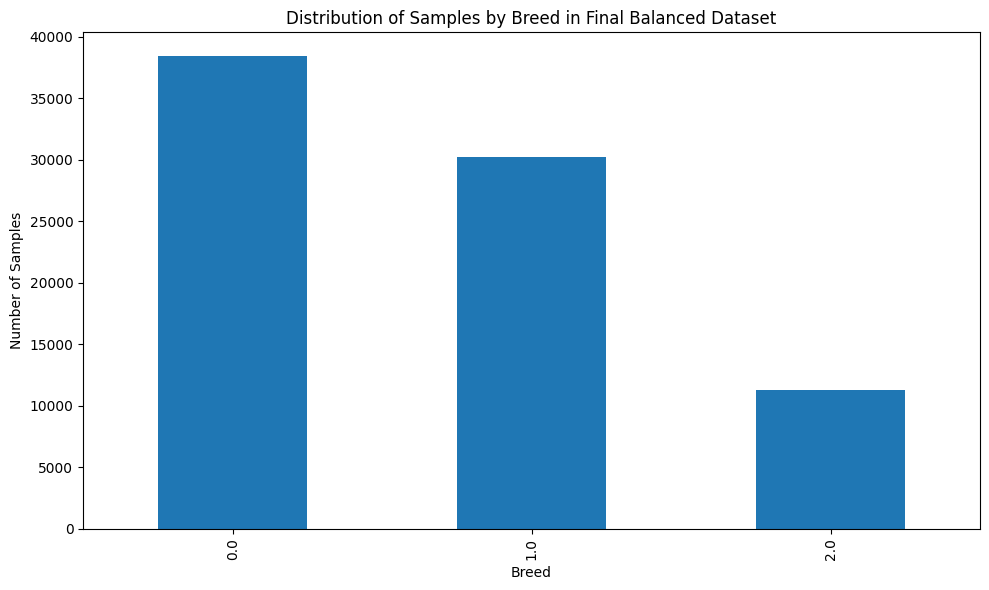

In [8]:
import matplotlib.pyplot as plt

# Group final_balanced_df by 'breed' and count the number of samples per breed.
# breed_counts = final_balanced_df[final_balanced_df['Breed'] == 'ML105'].groupby(['Year']).size()
breed_counts = train_df.groupby(['class_label']).size()

# Create a bar chart.
plt.figure(figsize=(10, 6))
breed_counts.plot(kind='bar')
plt.xlabel('Breed')
plt.ylabel('Number of Samples')
plt.title('Distribution of Samples by Breed in Final Balanced Dataset')
plt.tight_layout()
plt.show()


In [22]:
output_csv = "./data/multiple_2025/"
os.makedirs(output_csv, exist_ok=True)

In [23]:
final_balanced_df.to_csv(output_csv+ 'final_balanced_df.csv',index=False)
train_df.to_csv(output_csv + 'train_balanced_df.csv',index=False)
valid_df.to_csv(output_csv + 'valid_balanced_df.csv',index=False)

In [24]:
import os
import numpy as np
import pandas as pd

def load_data_from_npz(metadata_df, npz_dir):
   
    # Group metadata by folder identifier.
    grouped = metadata_df.groupby('keys_img_id_ac')
    images_list = []
    labels_list = []
    
    for key, group in grouped:
        # Build the file name using the key.
        # All files are labeled as 'train' (e.g., "000023_0000003_train.npz") because they come from the original train set.
        file_name = f"{key}_train.npz"
        file_path = os.path.join(npz_dir, file_name)
        
        if not os.path.exists(file_path):
            print(f"Warning: File {file_path} not found. Skipping this group.")
            continue
        
        # Load the npz file. Here we assume the array is stored under the key "kernel_pics".
        npz_data = np.load(file_path)
        images_array = npz_data["kernel_pics"]
        
        # For each record in this group, get the image using the local index.
        for idx in group["local_image_index"]:
            idx = int(idx)  # Ensure the index is an integer.
            if idx < 0 or idx >= images_array.shape[0]:
                print(f"Warning: local_image_index {idx} out of range for file {file_path}. Skipping.")
                continue
            images_list.append(images_array[idx])
            labels_list.append(key)  # Use keys_img_id_ac as the label.
    
    x = np.array(images_list)
    y = np.array(labels_list)
    return x, y

def load_train_valid(npz_dir, train_metadata_df, valid_metadata_df):
    
    x_train, y_train = load_data_from_npz(train_metadata_df, npz_dir)
    x_valid, y_valid = load_data_from_npz(valid_metadata_df, npz_dir)
    return x_train, y_train, x_valid, y_valid


train_metadata_df = pd.read_csv(output_csv + 'train_balanced_df.csv')
valid_metadata_df = pd.read_csv(output_csv + 'valid_balanced_df.csv')

# Define the directory where the npz files are stored.
npz_dir = "/workspace/media/nas/MP/hovernet/Split_Processed/Training_set/"

# Load the data.
x_train, y_train, x_valid, y_valid = load_train_valid(npz_dir, train_metadata_df, valid_metadata_df)
print("x_train shape:", x_train.shape)
print("x_valid shape:", x_valid.shape)


x_train shape: (135379, 224, 224, 3)
x_valid shape: (33843, 224, 224, 3)


In [25]:
import os
import numpy as np

def save_train_valid_data(x_train, y_train, x_valid, y_valid, output_dir):
    
    # Create the output directory if it doesn't exist.
    os.makedirs(output_dir, exist_ok=True)
    
    train_file = os.path.join(output_dir, "train_data.npz")
    valid_file = os.path.join(output_dir, "valid_data.npz")
    
    np.savez_compressed(train_file, x_train=x_train, y_train=y_train)
    np.savez_compressed(valid_file, x_valid=x_valid, y_valid=y_valid)
    
    print(f"Training data saved to: {train_file}")
    print(f"Validation data saved to: {valid_file}")

# ===== Example Usage =====
# Assuming x_train, y_train, x_valid, y_valid have been loaded already:
output_dir = "/workspace/media/nas/MP/hovernet/Split_Processed/multiple_3class_mali_gk6_gk79/"
os.makedirs(output_dir, exist_ok=True)
save_train_valid_data(x_train, y_train, x_valid, y_valid, output_dir)


Training data saved to: /workspace/media/nas/MP/hovernet/Split_Processed/Binary_CN1/train_data.npz
Validation data saved to: /workspace/media/nas/MP/hovernet/Split_Processed/Binary_CN1/valid_data.npz
